In [11]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import os

from custom_hmm import *

%matplotlib widget

sns.set_context('talk')

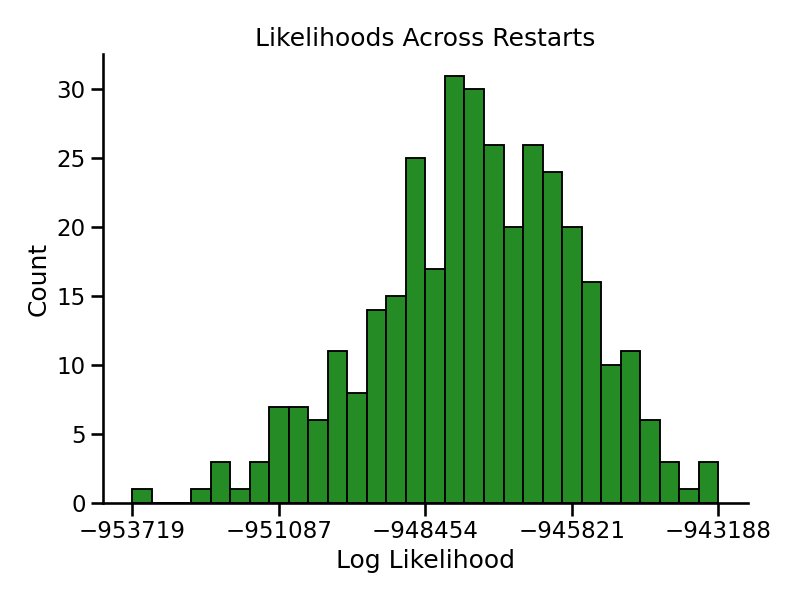

In [13]:
model_fits_dir = '/mnt/home/srafilson/code/sequences/results_pyr_only_20ms/full_fit/N_251'

# get the restarts
restarts = os.listdir(model_fits_dir)
restarts = [f for f in restarts if f.startswith("restart_")]

# load the likelihoods from the np file
likelihoods = np.load(f"{model_fits_dir}/likelihoods.npy")

# set zero likelihoods to -inf for better visualization
likelihoods[likelihoods == 0] = -np.inf


# plot the distribution of likelihoods across restarts
plt.figure(figsize=(8, 6))
sns.histplot(likelihoods, bins=30, color="forestgreen", alpha = 0.99)
plt.xlabel("Log Likelihood")
plt.title("Likelihoods Across Restarts")
plt.xticks(np.linspace(np.min(likelihoods[likelihoods != -np.inf]), np.max(likelihoods), 5))
plt.tight_layout()
sns.despine()
plt.show()


Best likelihood: -943188.3881164878 at restart restart_335


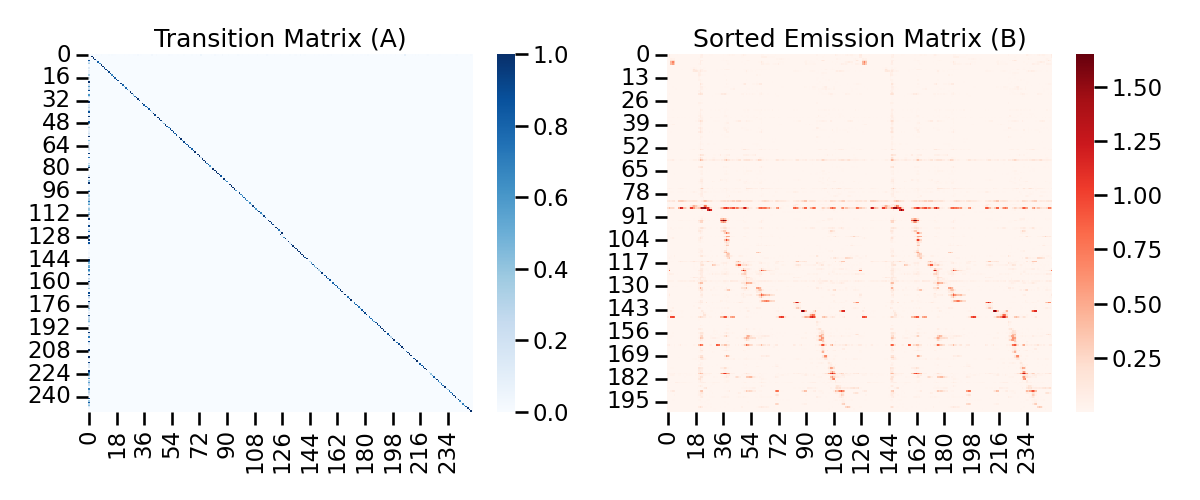

In [14]:
# get the best likelihood and corresponding parameters
sort_indices = np.argsort(likelihoods)

# get the best likelihood and corresponding parameters
best_idx = sort_indices[-1]


print(f"Best likelihood: {likelihoods[best_idx]} at restart {restarts[best_idx]}")

# get the parameters for the best fit
best_restart = restarts[best_idx]
best_data_path = f"{model_fits_dir}/{best_restart}/fitted_model.npz"
best_data = np.load(best_data_path, allow_pickle=True)

A = best_data["A"]
B = best_data["B"]
pi = best_data["pi"]
training_llh = best_data["training_likelihoods"]

# save A, B and pi to npz file
np.savez(f"/mnt/home/srafilson/code/sequences/co-smoothing-data/pyr_only_20ms_N251_better/best_fit_params.npz", A=A, B=B, pi=pi)
A, B, pi = np.load(f"/mnt/home/srafilson/code/sequences/co-smoothing-data/pyr_only_20ms_N251_better/best_fit_params.npz", allow_pickle=True).values()

# Reorder observation columns (neurons) according to the state that emits each observation with the highest probability.
state_order = np.argsort(np.argmax(B, axis=0))
B_sorted = B[:, state_order]

# normalize so area under each column is 1
B_sorted_normalized = stats.zscore(B_sorted, axis=0)

# plot the A and B matrices
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(A, ax=axs[0], cmap="Blues")
axs[0].set_title("Transition Matrix (A)")
sns.heatmap(B_sorted.T, ax=axs[1], cmap="Reds")
axs[1].set_title("Sorted Emission Matrix (B)")
plt.tight_layout()
plt.show()  



Loaded tracking data with 308232 timestamps and position shape (308232,) for x and (308232,) for y.


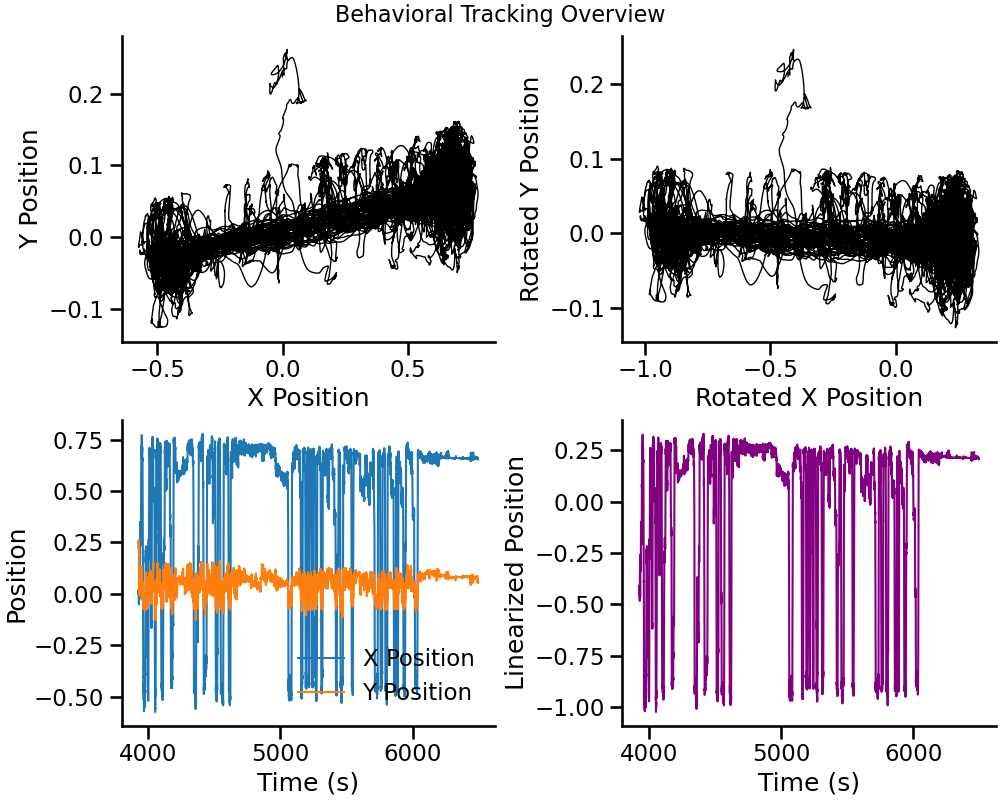

In [9]:
from scipy.io import loadmat
from sklearn.decomposition import PCA

# Loading the position tracking data
tracking_file = '/mnt/home/srafilson/ceph/Bilat_R02_20251106/Bilat_R02_20251106_imec0.tracking.behavior.mat'
tracking = loadmat(tracking_file, squeeze_me=True)['tracking']

tracking_timestamps = tracking['timestamps'].item() # these are timestamps in seconds which are aligned to the raw spike times
position = tracking['position'].item()
x, y = np.array(position['x'].item()), np.array(position['y'].item())
print(f'Loaded tracking data with {len(tracking_timestamps)} timestamps and position shape {x.shape} for x and {y.shape} for y.')

# do PCA to linearize the position
positions = np.vstack((x, y)).T
positions_fit_pca = positions[500:-500]

pca = PCA(n_components=1)

# fit PCA only on trimmed data
pca.fit(positions_fit_pca)

# project ALL positions onto the learned axis
linearized_position = pca.transform(positions).flatten()

start_behavior_time = tracking_timestamps[0]
end_behavior_time = tracking_timestamps[-1]



fig, axs = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)

# --- Top: XY trajectory ---
axs[0,0].plot(x, y, color="black", linewidth=1)
axs[0,0].set_xlabel("X Position")
axs[0,0].set_ylabel("Y Position")



# --- Bottom: Position over time ---
axs[1,0].plot(tracking_timestamps, x, label="X Position", linewidth=1.5)
axs[1,0].plot(tracking_timestamps, y, label="Y Position", linewidth=1.5)
axs[1,0].set_xlabel("Time (s)")
axs[1,0].set_ylabel("Position")
axs[1,0].legend(frameon=False)

# --- Optional: linearized position over time
axs[1,1].plot(tracking_timestamps, linearized_position, color="purple", linewidth=1.5)
axs[1,1].set_xlabel("Time (s)")
axs[1,1].set_ylabel("Linearized Position")


# rotate the XY trajectory by the angle of the first principal component for better visualization
angle = np.arctan2(pca.components_[0, 1], pca.components_[0, 0])

rotation_matrix = np.array([
    [np.cos(-angle), -np.sin(-angle)],
    [np.sin(-angle),  np.cos(-angle)]
])

rotated_positions = (positions - positions.mean(axis=0)) @ rotation_matrix.T
axs[0,1].plot(rotated_positions[:,0], rotated_positions[:,1], color="black", linewidth=1)
axs[0,1].set_xlabel("Rotated X Position")
axs[0,1].set_ylabel("Rotated Y Position")



sns.despine()
fig.suptitle("Behavioral Tracking Overview", fontsize=16)
plt.show()



In [10]:
# Load the spike count data
data_path = '/mnt/home/srafilson/code/sequences/data/maze_clipped_spike_counts_Bilat_R02_20251106.npz'
data = np.load(data_path, allow_pickle=True)

# set the number of position bins
n_bins = 50

# get the observations and true states from the data
observations = data["observations"]
print(f"Observations shape: {observations.shape}")
if "states" in data:
    true_states = data["states"]
else:
    true_states = None

if "time_bins" in data:
    time_bins = data["time_bins"]
else:
    time_bins = None


# resample the linearized position so that each position corresponds to a time bin in the observations
if time_bins is not None:
    # get the start and end time of the observations
    start_time = time_bins[0]
    end_time = time_bins[-1]

    # resample the linearized position to match the number of time bins in the observations
    linearized_position_resampled = np.interp(time_bins, tracking_timestamps, linearized_position)

    print(f"Resampled linearized position to match observations: {linearized_position_resampled.shape} vs {observations.shape[0]} time bins.")

    # bin the linearized position into discrete states (e.g., 10 bins)
    linearized_position_binned = np.digitize(linearized_position_resampled, bins=np.linspace(np.min(linearized_position_resampled), np.max(linearized_position_resampled), n_bins))
else:
    linearized_position_resampled = None
    linearized_position_binned = None
    print("No time_bins found in the data. Skipping resampling of linearized position.")



Observations shape: (130600, 307)
Resampled linearized position to match observations: (130600,) vs 130600 time bins.


In [ ]:
# now we will do leave-one-out co-smoothing for the model
model_likelihoods = []
for i in tqdm(range(observations.shape[1])):
    # leave out the i-th neuron
    train_observations = np.delete(observations, i, axis=1)
    test_observations = observations[:, i]

    # set the model with the transition matrix and emissions minus the left out neuron
    model = PoissonHMM(A, np.delete(B, i, axis=1), pi)

    # setting the observations minus the left out neuron
    model.set_observations(train_observations)

    # running the viterbi algorithm 
    states = model.viterbi()

    # now we can compute the likelihood of the left out observation given the inferred states
    log_likelihood = np.array(stats.poisson.logpmf(test_observations, B[:, i][states]))

    model_likelihoods.append(log_likelihood)

    # save to npy file
    np.save(f'model_likelihoods_all_times_251states.npy', np.array(model_likelihoods))
    



  0%|          | 0/307 [00:00<?, ?it/s]